In [149]:
from utility.plot_from_hdf5 import plot_from_hdf5
from utility.my_colors import palette_dark, palette_light

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

from matplotlib.patches import Patch
import matplotlib.colors as mcolors

RESULTS_PATH = "data/results.csv"
FIT_PARAMS_PATH = "data/fit_params.csv"
DETAILS_PATH = "data/result_details.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"

plt.rcdefaults()

settings = {
        'font.size':16,
#         # 'xtick.direction':'in', 
#         # 'xtick.minor.visible':True,
#         # 'xtick.top':True,
#         # 'ytick.direction':'in', 
#         # 'ytick.minor.visible':True,
#         # 'ytick.right':True,
#         # 'xtick.major.size':4.0,
#         # 'xtick.minor.size':2.0,
#         # 'ytick.major.size':4.0,
#         # 'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [3]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186890 entries, 39628261600268308 to 39627768828270015
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   rew_civ                  186890 non-null  float64
 1   rew_nv                   186890 non-null  float64
 2   rew_lya                  186890 non-null  float64
 3   snr_1700A                186888 non-null  float64
 4   snr_civ                  186890 non-null  float64
 5   snr_nv                   186890 non-null  float64
 6   snr_lya                  186890 non-null  float64
 7   pixel_used_civ           186890 non-null  float64
 8   pixel_used_blue_end_lya  186890 non-null  float64
 9   continuum_redchi         186890 non-null  float64
 10  z                        186890 non-null  float64
 11  zerr                     186890 non-null  float64
 12  civ_1549_flux            186890 non-null  float64
 13  civ_1549_flux_ivar       186890 non-n

### Check the subsequent samples like in Hamann
Objects that were processed (i.e. those from the initial SQL query) satisfy
`(zp.z BETWEEN 2.2 AND 4.38) AND (zp.zwarn=0) AND (agn.civ_1549_flux>0) AND (zp.spectype='QSO') AND zp.zcat_primary`

#### Full sample
- 2 < z 3.4 (lowest values are 2.2 not 2)
- warning=False which includes: SNR CIV > 2.5, continuum redchi2 < 2, all REW > 0 and not null, CIV at least 70% pixel used, Lya at least 65% pixel used on left side, z flux is larger 0 and not null

In [4]:
full = results[(results["z"] > 2) & (results["z"] < 3.4)].copy()
full["Sample"] = "Full"
full_idx = full.index
full

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,Full
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,Full
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,51.046492,63.236045,238.614723,241.211185,280.171174,5395.436113,5387.128039,4360.419360,0.234584,Full
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,Full
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,Full
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,45.596857,100.022424,84.395460,41.496963,78.308778,4527.744460,4535.865791,4139.097371,0.231864,Full
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,33.765478,41.641763,641.849498,428.851538,603.353178,6748.325156,6737.115628,5221.039957,0.242868,Full
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,32.918452,138.756640,197.663768,105.628622,450.723156,2341.986219,2341.278198,2033.014791,0.270749,Full


#### W3-detected
- SNR(W3) > 3

In [5]:
w3_detected = full.query("snr_w3 > 3").copy()
w3_detected["Sample"] = "W3 detected"
w3_detected_idx = w3_detected.index
w3_detected

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,W3 detected
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,W3 detected
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,W3 detected
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,W3 detected
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,43.567645,18.367051,101.499588,172.368010,57.564280,5503.989179,5494.918240,1743.896308,0.253387,W3 detected
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632961531806138,68.280006,61.465376,127.422601,0.520987,3.496122,3.179693,4.785442,0.933602,0.887892,0.083141,...,74.313305,145.025455,68.275819,67.038541,138.726613,5072.738838,5078.892571,6232.192289,0.262452,W3 detected
39627915016539584,32.306415,36.275146,19.276486,0.970341,10.217814,8.539332,6.160885,0.908676,0.783715,0.737209,...,45.084766,24.134494,616.826902,850.030266,465.566363,6061.770891,6051.918394,4207.913901,0.235826,W3 detected
39628382106812614,36.539355,31.760665,50.060707,0.803729,6.521420,5.596410,12.129493,0.982340,0.790588,0.060873,...,30.639997,50.611621,319.207859,328.347364,525.811885,4435.790432,4436.779084,2583.511499,0.234770,W3 detected


#### ERQs
- z-W3 > 3.9

In [6]:
erq = w3_detected[w3_detected["z-w3"] > 3.9].copy()
erq["Sample"] = "ERQ"
erq_idx = erq.index
erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,43.567645,18.367051,101.499588,172.368010,57.564280,5503.989179,5494.918240,1743.896308,0.253387,ERQ
39627699790024199,54.296104,49.135866,70.136264,0.736011,6.149229,4.306026,10.850016,0.966667,0.767742,0.470200,...,46.295448,72.000721,269.308325,270.468872,392.309264,4810.223967,4802.497872,2880.468972,0.301892,ERQ
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,74.504683,408.076060,74.910659,42.058782,280.985594,2736.066292,2736.942211,2436.999237,0.354027,ERQ
39628410783271554,89.148791,37.180647,54.512249,0.729147,4.183250,1.920362,4.650294,0.980296,0.872928,0.011805,...,41.075506,58.197953,250.329587,160.406223,245.082476,5333.544384,5324.768893,5147.189275,0.238072,ERQ
39628017118484156,69.084521,30.747853,65.695091,0.735615,3.597611,1.550206,2.602071,0.937238,0.842920,0.005644,...,38.555854,71.679024,109.690129,58.266969,128.186091,3098.068322,3101.563283,2681.904379,0.237146,ERQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628257213028100,58.748484,39.964032,95.143695,0.455924,3.710882,0.931673,4.008748,0.887133,0.879093,0.037589,...,38.808723,103.421342,57.212552,37.382676,88.044224,1544.838621,1548.736996,1742.937950,0.193428,ERQ
39627981827606141,43.335297,37.726595,33.696240,0.820696,3.186362,1.079839,3.451561,0.958025,0.903846,0.022352,...,31.636476,33.417698,93.913667,85.048706,76.108319,5886.729163,5877.097949,3141.389888,0.227888,ERQ
39627567950466529,27.040848,9.697804,36.252028,0.582844,4.036805,2.470379,8.181252,0.917526,0.747706,0.079300,...,22.278524,49.139704,204.505576,84.783761,328.567986,7352.573994,7364.694387,4137.069754,0.296886,ERQ


#### Core ERQs
- REW(CIV) > 100

In [7]:
core_erq = erq[erq["rew_civ"] > 100]
core_erq_idx = core_erq.index
core_erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,74.504683,408.076060,74.910659,42.058782,280.985594,2736.066292,2736.942211,2436.999237,0.354027,ERQ
39628072797866727,470.986602,93.509273,315.010605,0.552134,4.489033,1.061074,3.148873,0.953431,0.923497,0.011409,...,121.484755,337.753605,137.813298,37.926078,130.347061,3531.641976,3526.612645,2230.649285,0.241008,ERQ
39627891113201923,112.219588,62.672895,99.054101,0.606324,5.955274,2.710882,7.278569,0.983945,0.908163,0.016740,...,64.175805,97.136269,168.987387,121.849523,196.661733,7779.767027,7766.704920,2365.939453,0.372357,ERQ
39627780903669053,140.798530,249.117161,53.101180,0.543534,4.137893,5.718557,1.320132,0.901119,0.854470,0.004901,...,299.202272,138.779761,63.974277,105.536849,22.320187,2529.297899,2530.247288,6773.692334,0.351498,ERQ
39628396275177020,171.882397,39.498231,197.261087,0.697958,4.498471,0.809909,6.562073,0.978599,0.891540,0.002679,...,29.507003,190.096757,177.606102,60.731517,310.860502,4464.904177,4472.554377,1887.898275,0.235758,ERQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632971719774209,107.142013,40.204052,90.573330,0.451184,2.535676,0.928699,2.889068,0.950237,0.883905,0.026021,...,52.817816,106.850193,82.582710,35.124023,81.524699,6280.214439,6276.672312,3343.599854,0.244395,ERQ
39627606353513953,262.600709,133.373283,372.368041,0.875102,4.632945,2.508304,5.879460,0.912281,0.878049,0.042191,...,143.146019,404.085167,68.373912,51.797066,141.663679,1881.783099,1883.899711,1873.157476,0.352662,ERQ
39627897656312134,177.743800,54.117060,459.072967,1.142572,3.396098,0.698038,2.474661,0.840580,0.902965,0.022673,...,48.875308,509.715404,46.574391,15.453301,130.559180,1368.113618,1369.526758,1742.997973,0.372517,ERQ


#### REW(CIV) > 100

In [8]:
large = full.query("rew_civ > 100").copy()
large["Sample"] = "Large"
large

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628412662323165,161.601504,66.853313,24.886163,0.661391,5.145252,2.287900,1.508265,0.990172,0.836066,0.051041,...,97.918390,46.506675,312.551058,172.708966,66.286349,6157.448766,6147.276882,3865.514543,0.231917,Large
39628481855754778,149.066299,45.077878,88.992064,0.626327,4.060759,1.097277,2.594436,0.956190,0.881356,0.008430,...,52.837864,110.339125,111.886956,36.090498,72.030086,4415.217735,4407.751356,4426.295422,0.248055,Large
39627985698953905,134.089950,59.402374,94.582893,0.558191,8.832818,2.819567,7.060071,0.993135,0.884615,0.168216,...,59.768305,98.564059,528.413473,297.357835,484.507598,5025.185630,5016.763647,4696.221716,0.242982,Large
39627497754594111,107.996366,35.047851,123.960369,0.423711,6.565238,1.992941,7.510495,0.963325,0.925824,0.083516,...,35.319866,123.191551,233.432668,104.124874,380.926539,3380.669722,3376.700628,2172.249027,0.275029,Large
39628495797618139,181.144207,35.396888,159.440111,0.747491,3.404237,1.493232,2.868796,0.917595,0.863524,0.026513,...,66.708317,202.723108,94.571626,21.993908,100.743943,5329.609541,5320.673323,5787.762262,0.245590,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39627766093584889,100.659055,34.724141,74.987139,0.694299,4.940178,1.772425,5.475085,0.967442,0.888601,0.020050,...,44.420492,81.118414,197.145220,88.004187,194.620464,5189.891896,5181.619930,2452.828302,0.229893,Large
39628337403923861,104.989620,31.105850,101.069486,0.652475,4.819678,0.978631,3.843473,0.977612,0.889197,0.066478,...,31.079209,98.970324,208.883345,87.152896,291.297392,4813.784514,4805.810946,2203.319066,0.240380,Large
39628259347926729,113.953401,41.878910,118.952360,0.715565,4.402226,1.670195,2.452027,0.949398,0.908602,0.030174,...,55.373829,144.621351,107.152716,41.973889,120.600626,4294.859877,4297.107847,6293.627562,0.282238,Large


#### ERQ-like

In [9]:
# erq_like = results[(results["flux_z"] > 0) & (~results["flux_z"].isna()) & ~results["flag_civ"] & (results["z"] > 2) & (results["z"] < 4) & (results["snr_w3"] > 3) & (results["z-w3"] > 3.9) & (results["rew_civ"] > 100)]
# erq_like

### Plots

In [10]:
full = full.drop(index=["39627636372146550"])  # super large CIV REW

#### Evaluate method

#### Histogram: REW colored by object type

In [99]:
# histplot_df = full.copy()

# histplot_df["Sample"] = "Full"
# temp1 = erw

# for elem in histplot_df.index:
#     # if elem in core_erq_idx: 
#     if elem in erq_idx:
#         histplot_df.loc[elem,"Sample"] = "ERQ"
#     elif elem in w3_detected_idx:
#         histplot_df.loc[elem,"Sample"] = "W3 detected"
histplot_df = pd.concat([full,w3_detected,erq]).reset_index(drop=False)

histplot_df["Sample"].value_counts()

hue_order = ["Full", "W3 detected", "ERQ"]
hist_palette = ["gray", palette_dark[2], palette_dark[0]]

[]

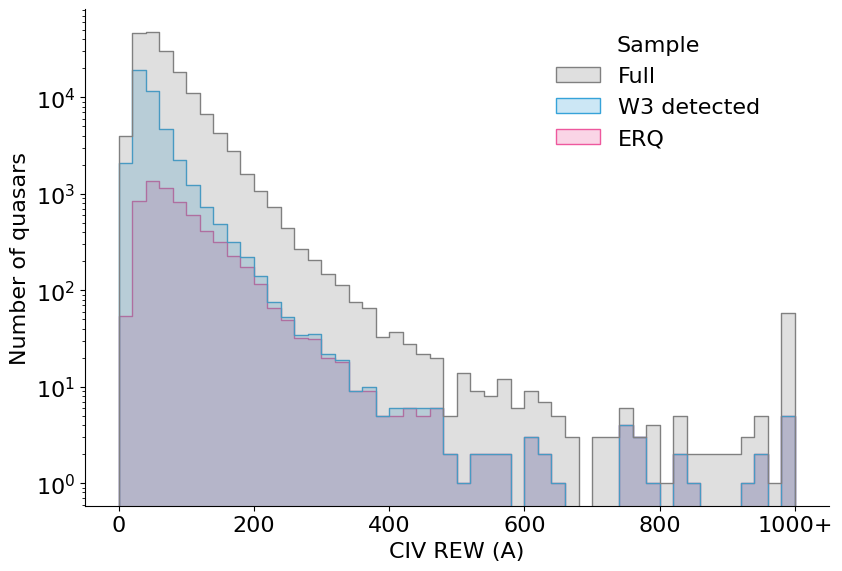

In [ ]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

civ_histplot = histplot_df[["rew_civ", "fwhm_civ","Sample"]].copy()

civ_histplot["rew_civ"] = civ_histplot["rew_civ"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=civ_histplot, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

xticks = list(range(0,1001,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "1000+"
ax.set_xticklabels(xticklabels)

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("CIV REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

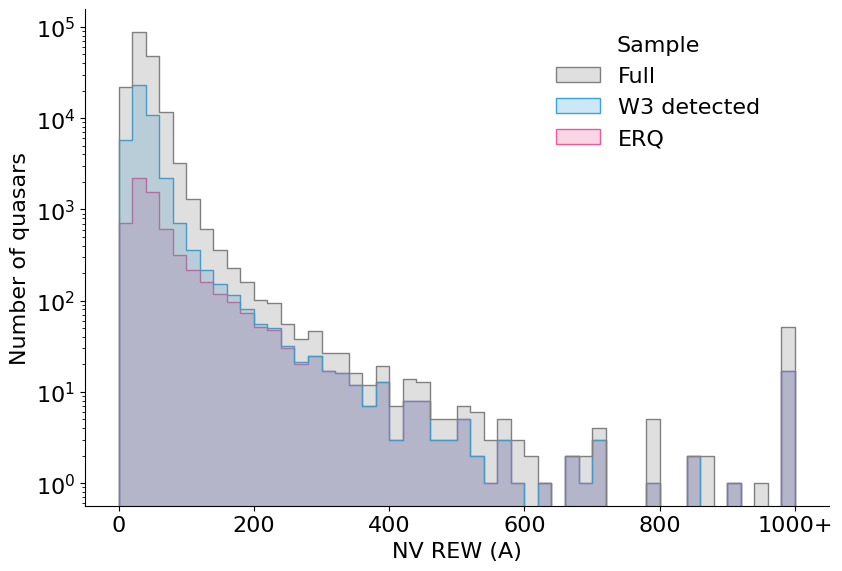

In [ ]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

nv_histplot = histplot_df[["rew_nv","fwhm_nv","Sample"]].copy()

nv_histplot["rew_nv"] = nv_histplot["rew_nv"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=nv_histplot, x="rew_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

# plt.xlim(-5,1005)

xticks = list(range(0,1001,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "1000+"
ax.set_xticklabels(xticklabels)

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("NV REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

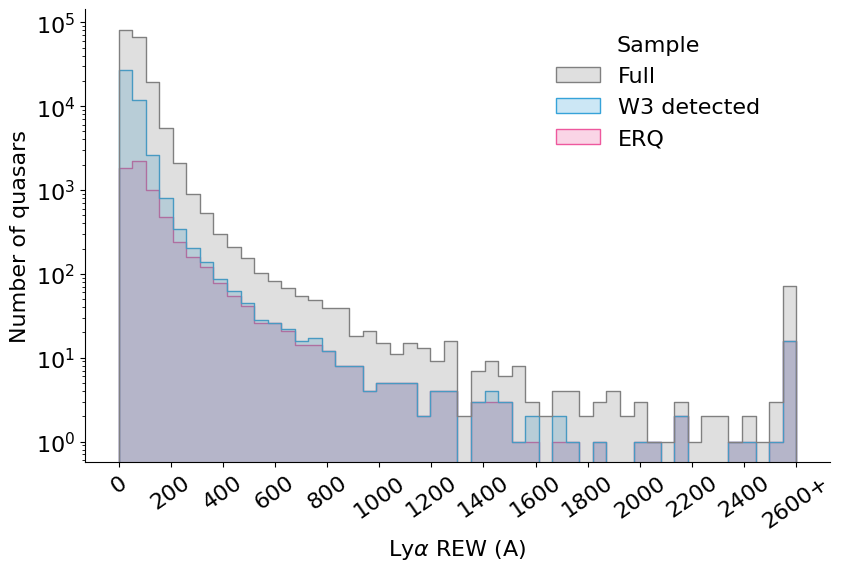

In [ ]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

lya_histplot = histplot_df[["rew_lya","fwhm_lya","Sample"]].copy()#

lya_histplot["rew_lya"] = lya_histplot["rew_lya"].clip(upper=2600)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=lya_histplot, x="rew_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")


xticks = list(range(0,2601,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "2600+"
ax.set_xticklabels(xticklabels,rotation=35)


sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel(r"Ly$\alpha$ REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

#### Histogram: FWHM colored by object type

[]

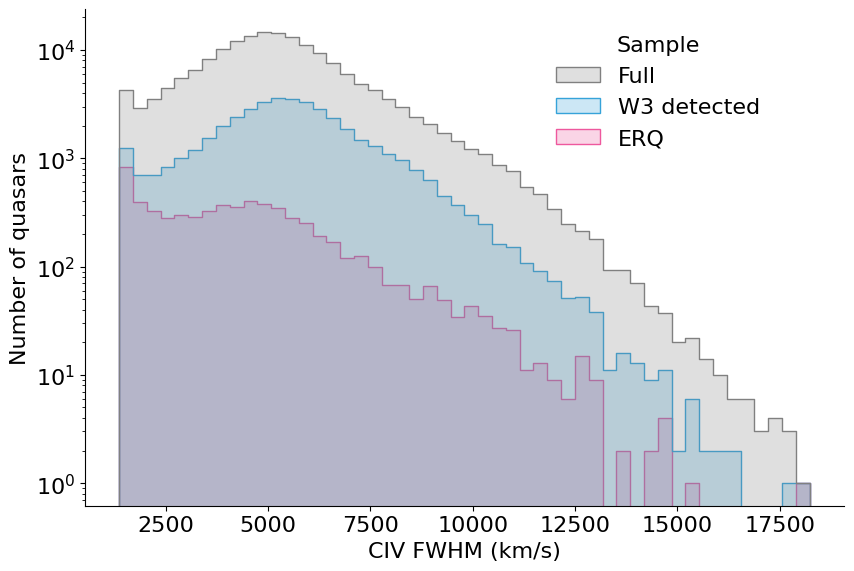

In [ ]:
g = sns.displot(data=civ_histplot, x="fwhm_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("CIV FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

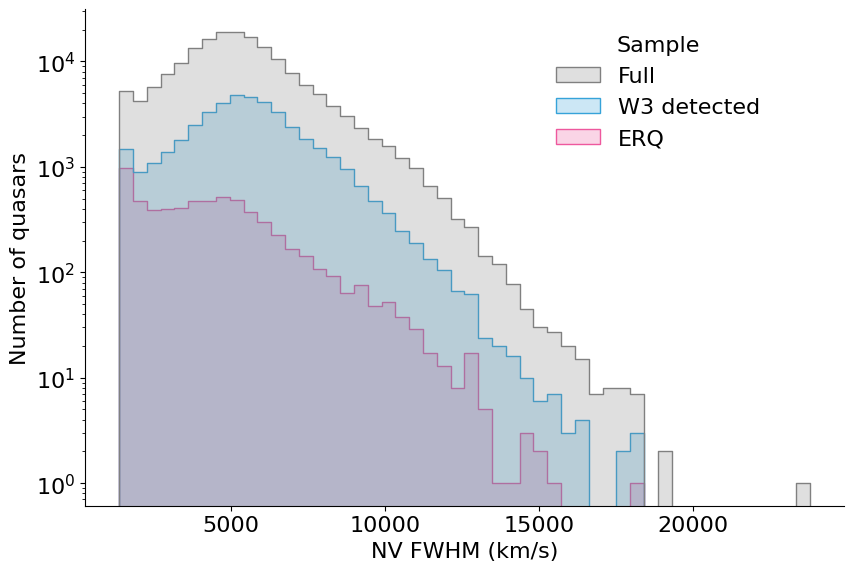

In [ ]:
g = sns.displot(data=nv_histplot, x="fwhm_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("NV FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

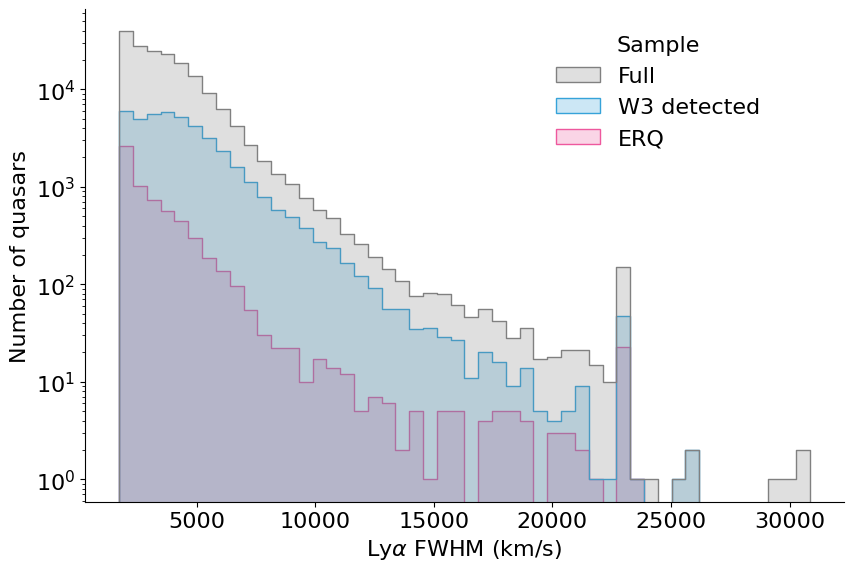

In [ ]:
g = sns.displot(data=lya_histplot, x="fwhm_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel(r"Ly$\alpha$ FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

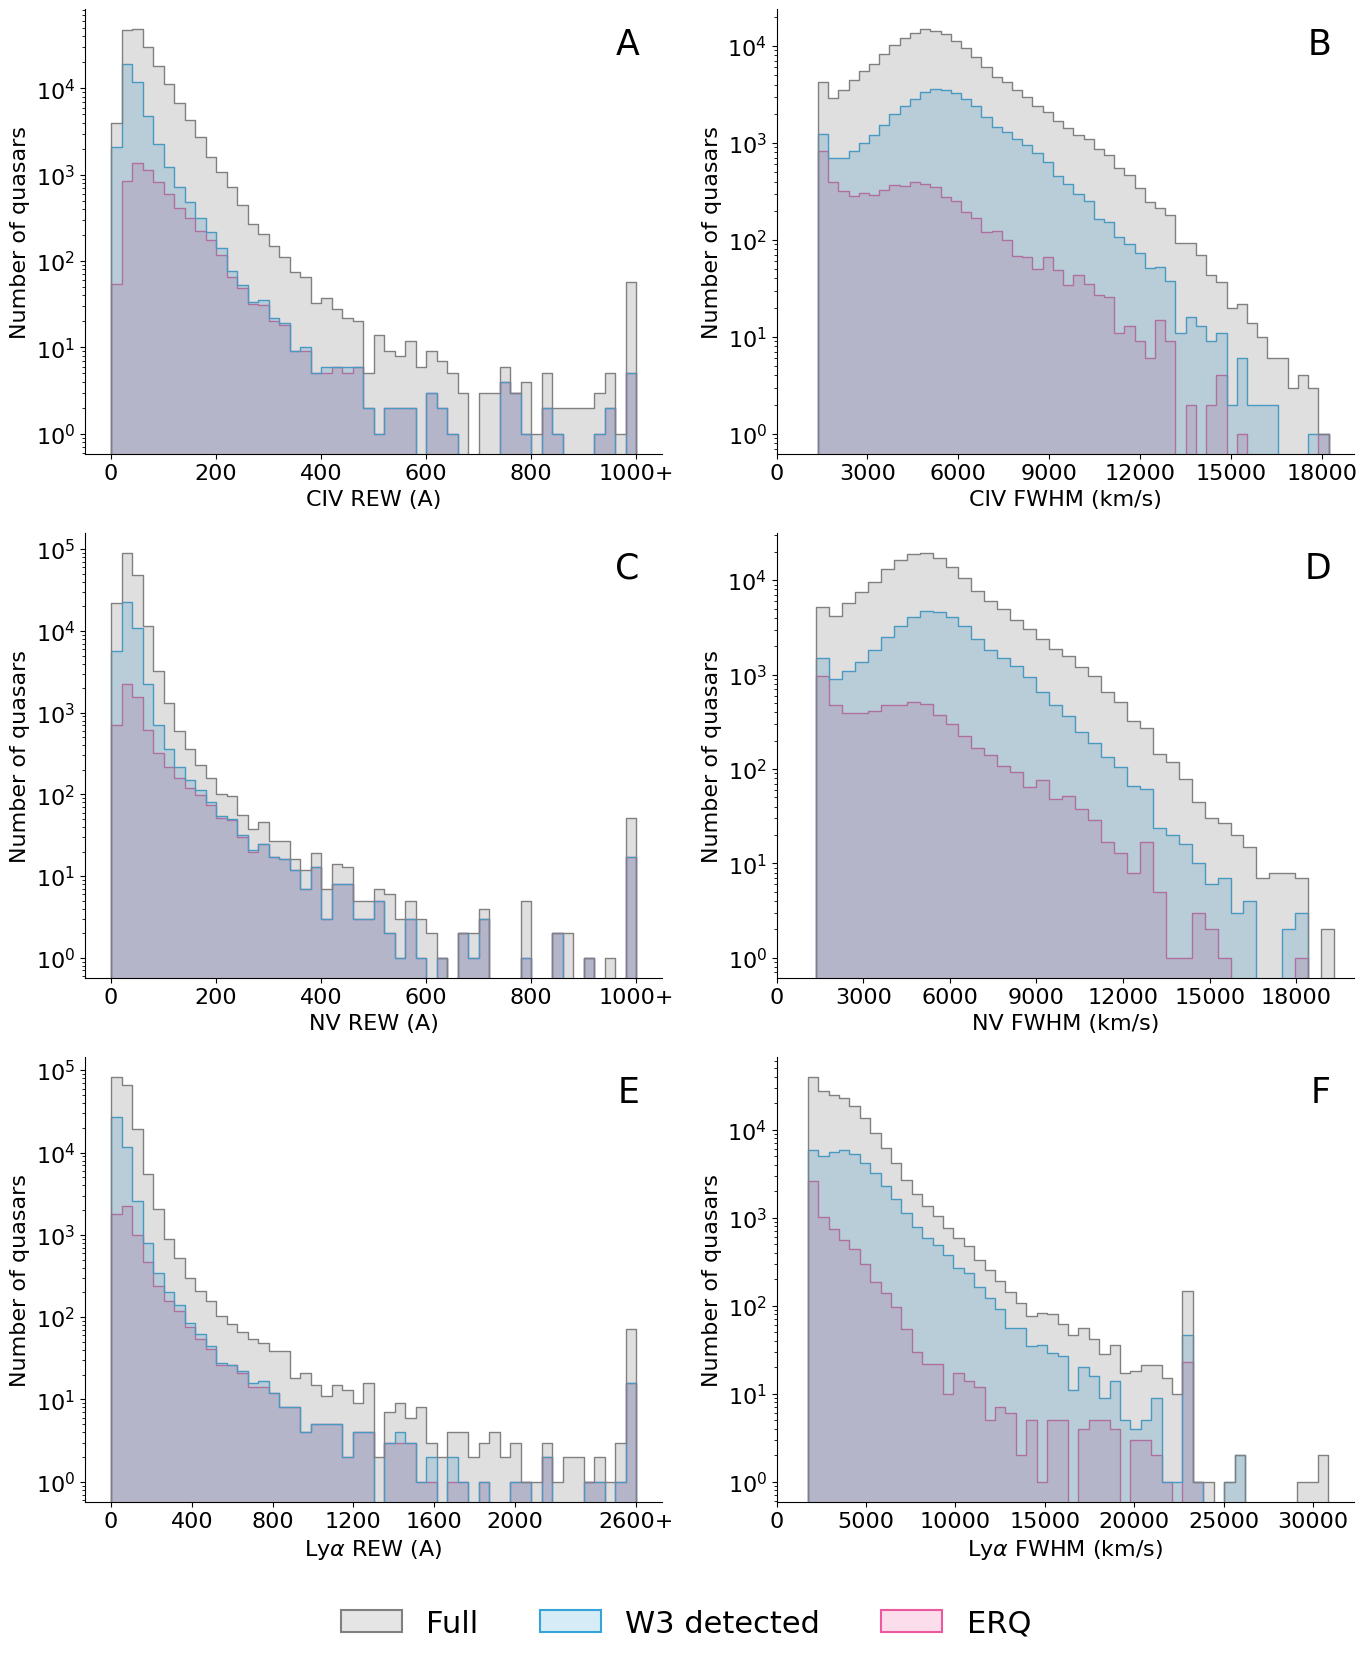

In [160]:
fig, ax = plt.subplots(3,2,figsize=(14,16))


## CIV REW [0,0]

sns.histplot(data=civ_histplot, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[0,0],legend=False)

ax[0,0].set_yscale("log")

xticks_00 = list(range(0,1001,200))
ax[0,0].set_xticks(xticks_00)
xticklabels_00 = [str(int(t)) for t in xticks_00]
xticklabels_00[-1] = "1000+"
ax[0,0].set_xticklabels(xticklabels_00)

ax[0,0].set_xlabel("CIV REW (A)")
ax[0,0].set_ylabel("Number of quasars")
ax[0,0].spines[['right', 'top']].set_visible(False)


## CIV FWHM [0,1]

sns.histplot(data=civ_histplot, x="fwhm_civ", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[0,1],legend=False)

ax[0,1].set_yscale("log")

xticks_01 = list(range(0,18001,3000))
ax[0,1].set_xticks(xticks_01)

ax[0,1].set_xlabel("CIV FWHM (km/s)")
ax[0,1].set_ylabel("Number of quasars")
ax[0,1].spines[['right', 'top']].set_visible(False)


## NV REW [1,0]

sns.histplot(data=nv_histplot, x="rew_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[1,0],legend=False)

ax[1,0].set_yscale("log")

xticks_10 = list(range(0,1001,200))
ax[1,0].set_xticks(xticks_10)
xticklabels_10 = [str(int(t)) for t in xticks_10]
xticklabels_10[-1] = "1000+"
ax[1,0].set_xticklabels(xticklabels_10)

ax[1,0].set_xlabel("NV REW (A)")
ax[1,0].set_ylabel("Number of quasars")
ax[1,0].spines[['right', 'top']].set_visible(False)


## NV FWHM [1,1]

sns.histplot(data=nv_histplot, x="fwhm_nv", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[1,1],legend=False)

ax[1,1].set_yscale("log")

xticks_11 = list(range(0,18001,3000))
ax[1,1].set_xticks(xticks_11)

lower_x_11, _ = ax[1,1].get_xlim()
ax[1,1].set_xlim(lower_x_11, 20000)

ax[1,1].set_xlabel("NV FWHM (km/s)")
ax[1,1].set_ylabel("Number of quasars")
ax[1,1].spines[['right', 'top']].set_visible(False)


## LYA REW [2,0]

sns.histplot(data=lya_histplot, x="rew_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[2,0],legend=False)

ax[2,0].set_yscale("log")

xticks_20 = list(range(0,2001,400))+[2600]
ax[2,0].set_xticks(xticks_20)
xticklabels_20 = [str(int(t)) for t in xticks_20]
xticklabels_20[-1] = "2600+"
ax[2,0].set_xticklabels(xticklabels_20)

ax[2,0].set_xlabel(r"Ly$\alpha$ REW (A)")
ax[2,0].set_ylabel("Number of quasars")
ax[2,0].spines[['right', 'top']].set_visible(False)


## LYA FWHM [2,1]

sns.histplot(data=lya_histplot, x="fwhm_lya", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[2,1],legend=False)

ax[2,1].set_yscale("log")

ax[2,1].set_xlabel(r"Ly$\alpha$ FWHM (km/s)")
ax[2,1].set_ylabel("Number of quasars")
ax[2,1].spines[['right', 'top']].set_visible(False)

xticks_21 = ax[2,1].get_xticks()
ax[2,1].set_xticks([0]+xticks_21[:-1])

## GLOBAL STYLE THINGS

# letters in upper right corner
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for a, letter in zip(ax.flat, labels):
    a.text(
        0.96, 0.96, f"{letter}",
        transform=a.transAxes,
        ha='right', va='top',
        fontsize=25,
    )

# legend
handles = [
    Patch(
        facecolor=mcolors.to_rgba(c, alpha=0.2),  # transparent fill
        edgecolor=c,
        linewidth=1.5,
    )
    for c in palette
]

leg = fig.legend(
    handles, hue_order,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(handles),
    frameon=False,
    fontsize=22,
    markerscale=4
)


plt.tight_layout()

# plt.savefig("images/histograms_v1.svg")

plt.show()

In [150]:
full[["fwhm_civ","fwhm_nv","fwhm_lya"]].describe()

,fwhm_civ,fwhm_nv,fwhm_lya
count,177400.000000,177346.000000,177358.000000
mean,5345.673061,5341.747184,3847.425869
std,2069.283645,2070.355572,2025.266506
min,1367.210673,1365.329927,1742.625254
25%,4021.318813,4018.672102,2415.315973
50%,5135.252247,5129.526504,3407.591604
75%,6380.020705,6372.251249,4628.304305
max,18229.332175,23788.928605,30844.539955


In [154]:
(full["fwhm_civ"] > 2000).mean()

0.9613852179548592

#### i-W3 histogram

In [55]:
color_hist_df = w3_detected[w3_detected["rew_civ"]>150].copy()
color_hist_df["Sample"] = "REW(CIV) > 150"
color_hist_df = pd.concat([color_hist_df,w3_detected])[["z-w3","Sample"]]

# color_hist_df

[]

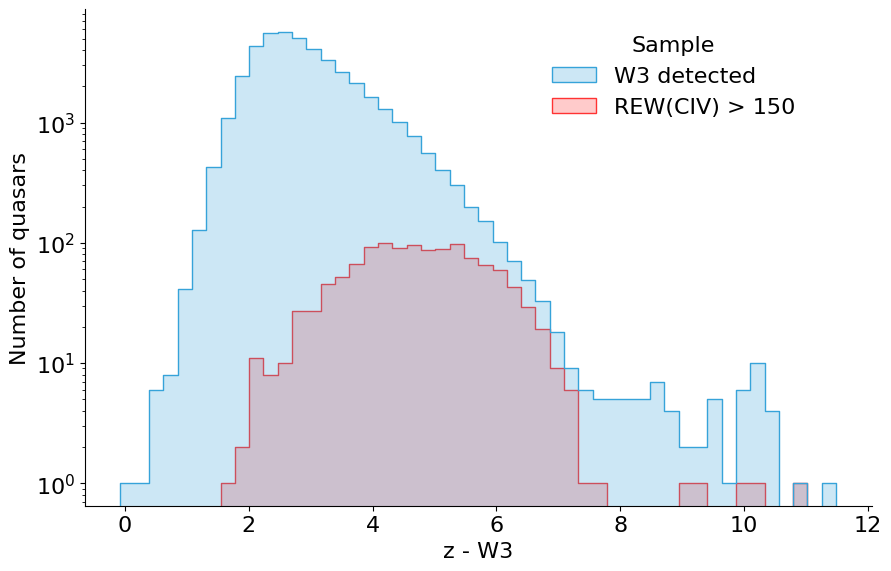

In [56]:
g = sns.displot(data=color_hist_df, x="z-w3", hue="Sample",bins=50,element="step",hue_order=["W3 detected","REW(CIV) > 150"],palette=[palette_dark[2],palette_dark[5]],height=6,aspect=1.1)

plt.yscale("log")

plt.xlabel("z - W3")
plt.ylabel("Number of quasars")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.tight_layout()

plt.plot()

#### NV/CIV vs color

In [57]:
# dataframe where the subsets are not duplicate like for the histograms
flux_ratio_df = w3_detected[["z-w3","flux_civ","flux_nv","flux_lya","rew_civ","kt80_civ","Sample","z"]].copy()
flux_ratio_df["nv/civ"] = flux_ratio_df["flux_nv"] / flux_ratio_df["flux_civ"]

for elem in flux_ratio_df.index:
    if flux_ratio_df.loc[elem,"rew_civ"] > 100:
        flux_ratio_df.loc[elem,"Sample"] = "REW(CIV) > 100"

flux_ratio_df = flux_ratio_df.reset_index()

In [58]:
flux_ratio_df.groupby("Sample")["nv/civ"].describe().T

Sample,REW(CIV) > 100,W3 detected
count,3445.000000,40174.000000
mean,0.630098,1.099051
std,0.370795,0.488281
min,-0.071507,-0.023724
25%,0.389115,0.758665
50%,0.539349,1.055576
75%,0.738490,1.395429
max,2.430436,10.156943


(-0.1, 3.5)

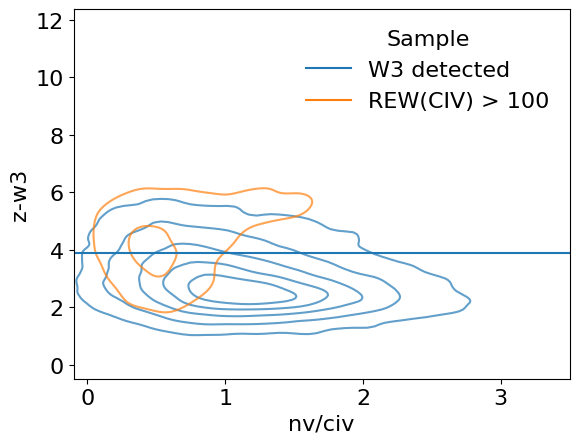

In [59]:
# sns.scatterplot(data=flux_ratio_df,x="nv/civ",y="z-w3",hue="Sample",size=1,alpha=0.4)

sns.kdeplot(data=flux_ratio_df,x="nv/civ",y="z-w3",hue="Sample",fill=False,thresh=0.05,alpha=0.7,levels=6)

plt.axhline(y=3.9)

plt.xlim(-0.1,3.5)

#### kt80 vs color

In [60]:
flux_ratio_df["kt80_civ"].describe()

count    42082.000000
mean         0.277872
std          0.052412
min          0.170672
25%          0.238326
50%          0.258527
75%          0.307475
max          0.542334
Name: kt80_civ, dtype: float64

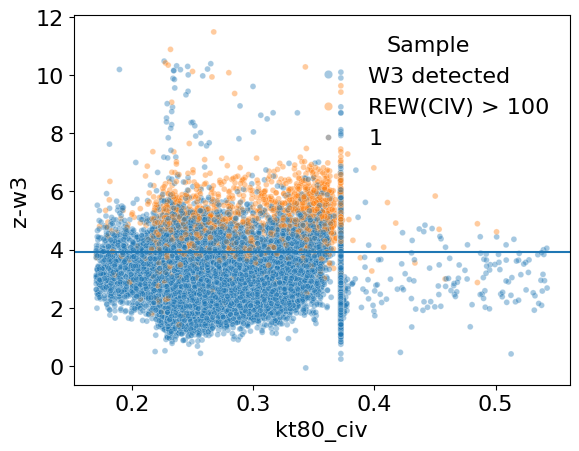

In [83]:
sns.scatterplot(data=flux_ratio_df,x="kt80_civ",y="z-w3",hue="Sample",size=1,alpha=0.4)

# sns.kdeplot(data=flux_ratio_df,x="kt80_civ",y="z-w3",hue="Sample",fill=False,thresh=0.05,alpha=0.7,levels=6)

plt.axhline(y=3.9)

# plt.xlim(-0.1,3.5)

#### Contour plot: z vs color

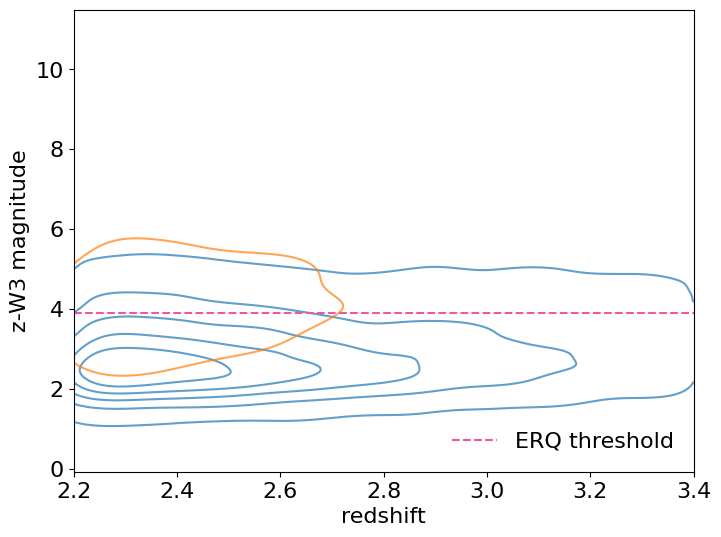

In [ ]:
# plt.hist2d(w3_detected["z"],w3_detected["z-w3"])
fig, ax = plt.subplots(figsize=(8,6))
sns.kdeplot(data=flux_ratio_df,x="z",y="z-w3",hue="Sample",fill=False,cut=0,label="W3 detected",thresh=0.05,alpha=0.7,levels=6,ax=ax)#color="#442222"
# plt.scatter(large["z"],large["z-w3"],s=0.1,alpha=0.9,color=palette_dark[2],label="REW(CIV) > 100")
# sns.kdeplot(data=large,x="z",y="z-w3",fill=False,color=palette_dark[2],cut=0,label="REW(CIV) > 100",thresh=0.05,alpha=0.7,levels=6,ax=ax)

plt.axhline(3.9,label="ERQ threshold",color=palette_dark[0],linestyle="--")

# lower_ylim, upper_ylim = ax.get_ylim()
# plt.axhspan(3.9,upper_ylim, color=palette_dark[0], alpha=0.3)

plt.xlim(2.2,3.4)
# plt.ylim(lower_ylim,upper_ylim)
leg = plt.legend(frameon=False,markerscale=18,loc="lower right")

        
plt.xlabel("redshift")
plt.ylabel("z-W3 magnitude")

# plt.tight_layout()

# plt.savefig("images/contour.svg")

plt.show()

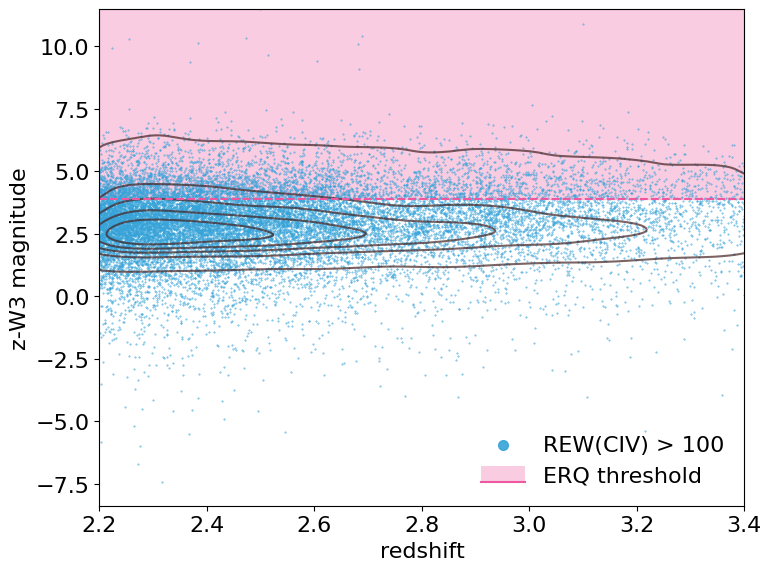

In [ ]:
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

class HandlerShadedBottomBorder(HandlerBase):
    """Legend handle: shaded box with a border only on the bottom edge."""
    def __init__(self, facecolor, edgecolor, alpha=0.3, linewidth=1.5, **kwargs):
        self.facecolor = facecolor
        self.edgecolor = edgecolor
        self.alpha = alpha
        self.linewidth = linewidth
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                        xdescent, ydescent, width, height, fontsize, trans):
        rect = Rectangle(
            (-xdescent, -ydescent), width, height,
            facecolor=self.facecolor, alpha=self.alpha,
            edgecolor="none", transform=trans
        )
        bottom_line = Line2D(
            [-xdescent, -xdescent + width], [-ydescent, -ydescent],
            color=self.edgecolor, linewidth=self.linewidth, transform=trans
        )
        return [rect, bottom_line]

fig, ax = plt.subplots(figsize=(8,6))
sns.kdeplot(data=w3_detected,x="z",y="z-w3",fill=False,color="#442222",
            cut=0,label="W3 detected",thresh=1E-02,alpha=0.7,levels=6,ax=ax)

# lower_ylim, upper_ylim = ax.get_ylim()
plt.axhspan(3.9,upper_ylim, color=palette_dark[0], alpha=0.3)

plt.scatter(large["z"],large["z-w3"],s=0.15,alpha=0.9,color=palette_dark[2],label="REW(CIV) > 100")

plt.axhline(3.9,color=palette_dark[0],linestyle="--")  # no label now, legend entry built manually



plt.xlim(2.2,3.4)
plt.ylim(lower_ylim,upper_ylim)

# proxy handle for the custom legend entry
erq_proxy = Patch(facecolor="none", edgecolor="none", label="ERQ threshold")

handles, labels = ax.get_legend_handles_labels()
handles.append(erq_proxy)
labels.append("ERQ threshold")

leg = ax.legend(
    handles, labels,
    frameon=False, markerscale=18, loc="lower right",
    handler_map={erq_proxy: HandlerShadedBottomBorder(
        facecolor=palette_dark[0], edgecolor=palette_dark[0], alpha=0.3, linewidth=1.5
    )}
)

plt.xlabel("redshift")
plt.ylabel("z-W3 magnitude")

plt.tight_layout()

# plt.savefig("images/contour v2.svg")

plt.show()

In [ ]:
# i = 1578

# targetid = "39627636372146550"#core_erq.index[i]

# plot_from_hdf5(targetid,CIV=True,NV=True,LYA=True,smoothing_strength=6,title=full.loc[targetid,"desiname"])

### nv/civ flux ratio

In [ ]:
# load and filter details
details = pd.read_csv(DETAILS_PATH,index_col=0,dtype={"targetid":"str"})
details = details[details["targetid"].isin(full.index)]

details = details.set_index("targetid")

# # extract flux values
details["flux_civ"] = details["measurements_civ"].apply(lambda x: ast.literal_eval(str(x))["further_measurements"]["line_flux"] if x != np.nan else None)
details["flux_nv"] = details["measurements_nv"].apply(lambda x: ast.literal_eval(str(x))["further_measurements"]["line_flux"] if x != np.nan else None)
details["flux_lya"] = details["measurements_lya"].apply(lambda x: ast.literal_eval(str(x))["further_measurements"]["line_flux"] if x != np.nan else None)

det

In [ ]:
details["nv/civ"] = details["flux_nv"] / details["flux_civ"]

In [ ]:
details["nv/civ"].describe()

count    188333.000000
mean          0.846825
std           4.417008
min        -257.076335
25%           0.522992
50%           0.775273
75%           1.102058
max        1621.903421
Name: nv/civ, dtype: float64

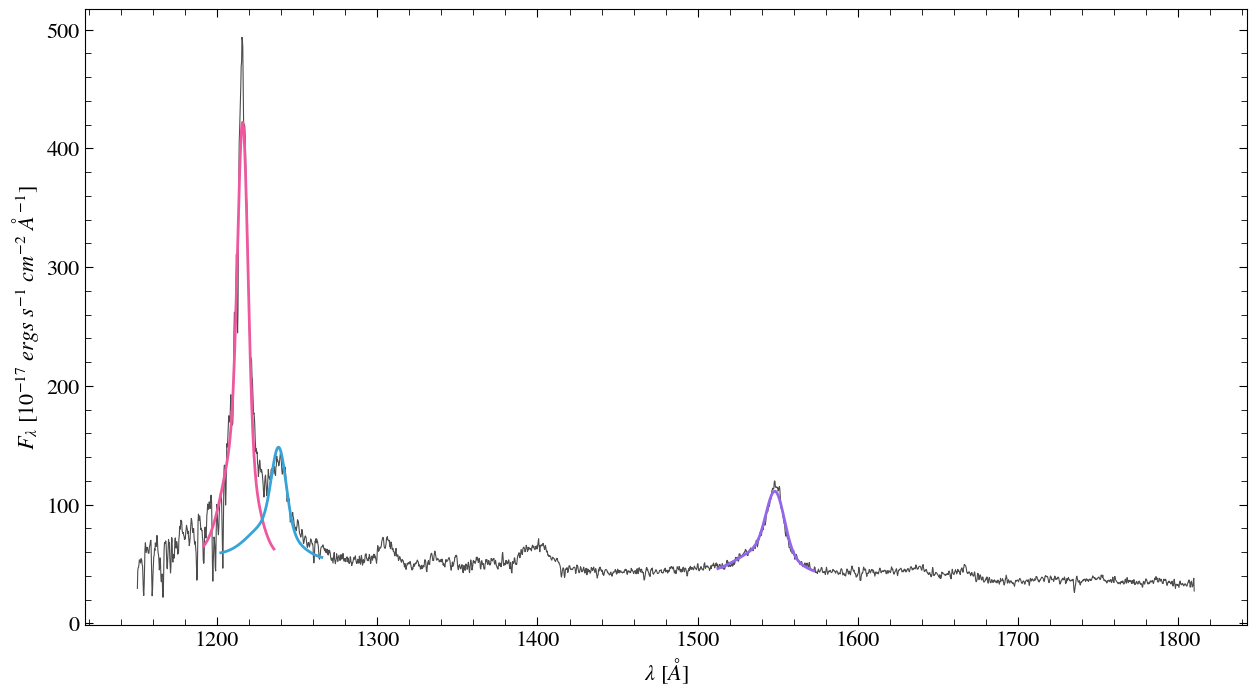

In [ ]:
plot_from_hdf5(39628261600268308,df=details,LYA=True,CIV=True,NV=True)